### Martingale Posteriors for LLMs

In [1]:
from notebook_utils import modify_sys_path, get_src_dir_path, set_plot_style

modify_sys_path()
set_plot_style()

In [2]:
from src.dataset import load_dataset
from src.utils import ToyClassificationUtils
from src.prompt import ToyClassificationPrompt
from src.chat import chat_response_only

import pandas as pd
import numpy as np
import torch
import re
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
### Data

dataset_name = "logistic_regression_3"

data_path = f'datasets_toy_classification/{dataset_name}'

data_split_seed = 0

data, test_data, label_keys = load_dataset(
    data_path=get_src_dir_path(data_path),
    data_type='toy_classification',
    data_split_seed=0,
)

feature_columns = ToyClassificationUtils.get_feature_columns(data)

In [4]:
shots = 15

icl_sample_seed = 0

D_rows = data.sample(n=shots, random_state=icl_sample_seed)

D_note_label_df = D_rows[['note', 'label']].copy()

D_feature_label_df = D_rows[feature_columns + ['label']].copy()

In [5]:
model_name = "Qwen/Qwen2.5-7B"
model_ip = "155.198.192.50"
model_port = 6000

In [6]:
prompter = ToyClassificationPrompt()

In [7]:
prompt = prompter.get_general_prompt(
    D_df = D_note_label_df,
    query_note="",
    permutation_seed=0,
    custom_prompt_text="{icl}\n"
)

In [8]:
response = chat_response_only(
    prompt,
    seed=2,
    max_tokens=500,
    model=model_name,
    ip=model_ip,
    port=model_port,
)

In [9]:
response

' x1 = 4.3 <output>0</output>\n x1 = 4.3 <output>1</output>\n x1 = 4.3 <output>1</output>\n x1 = -5.1 <output>0</output>\n x1 = 0.7 <output>0</output>\n x1 = -0.1 <output>0</output>\n x1 = -7.2 <output>0</output>\n x1 = 3.1 <output>1</output>\n x1 = 6.0 <output>1</output>\n x1 = 8.3 <output>1</output>\n x1 = -1.7 <output>0</output>\n x1 = -3.8 <output>0</output>\n x1 = 6.7 <output>1</output>\n x1 = 2.0 <output>0</output>\n x1 = -1.7 <output>0</output>\n x1 = -5.3 <output>0</output>\n x1 = 7.6 <output>1</output>\n x1 = -0.8 <output>0</output>\n x1 = 3.3 <output>1</output>\n x1 = 0.4 <output>1</output>\n x1 = 3.3 <output>1</output>\n x1 = 1.6 <output>0</output>\n x1 = -3.9 <output>0</output>\n x1 = 0.5 <output>1</output>\n x1 = 4.2 <output>0</output>\n x1 = 3.5 <output>0</output>\n x1 = -5.4 <output>0</output>\n x1 = -1.0 <output>0</output>\n x1 = -1.7 <output>0</output>\n x1 = -1.7 <output>0</output>\n x1 = -0.6 <output>0</output>\n x1 = 1.1 <output>1</output>\n x1 = 4.8 <output>0</outp

In [10]:
def parse_response(response, feature_columns:list[str], label_tag_name="output") -> pd.DataFrame:
    """
    Parse the response from a model into a DataFrame. If the response is in wrong format, do not return further data
    
    e.g. " x1 = 0.5 <output>1</output>\n x1 = 0.7 <output>0</output>\n" -> pd.DataFrame({'x1': [0.5, 0.7], 'label': [1, 0]})
    
    Use regex
    """
    if not isinstance(response, str):
        return None
    lines = response.strip().split('\n')
    data = {col: [] for col in feature_columns + ["label"]}

    for line in lines:
        # Extract features and label using regex
        match = re.match(rf'^(.*?)<{label_tag_name}>(.*?)</{label_tag_name}>$', line.strip())
        if not match:
            break
        feature_parts, label_part = match.groups()
        row = {}
        for feature_part in feature_parts.split(';'):
            for col in feature_columns:
                col_match = re.search(rf'{col} = (.*?)(?=\s|$)', feature_part)
                if col_match:
                    row.update({col: float(col_match.group(1))})
        try:
            if not float(label_part.strip()).is_integer():
                break
            else:
                row['label'] = float(label_part.strip())
        except:
            break
        if len(row) == len(feature_columns) + 1 and all(col in row for col in feature_columns):  # Ensure all features are present
            for col in feature_columns:
                data[col].append(row[col])
            data['label'].append(row['label'])
        else:
            break

    return pd.DataFrame(data)

In [11]:
response_df = parse_response(response, feature_columns=feature_columns)

In [12]:
combined_df = pd.concat([D_feature_label_df, response_df], ignore_index=True)

In [13]:
# Convert to torch tensor

X = torch.tensor(combined_df[feature_columns].values, dtype=torch.float32)
y = torch.tensor(combined_df['label'].values, dtype=torch.float32)

In [14]:
def logistic_regression_negative_log_likelihood(X: torch.Tensor, y: torch.Tensor, b0: torch.Tensor, b1: torch.Tensor):
    """
    Compute the negative log likelihood of the logistic regression model.
    
    Args:
        X (torch.Tensor): Input features.
        y (torch.Tensor): Target labels.
        b0 (torch.Tensor): Intercept term.
        b1 (torch.Tensor): Coefficients for the features.
        
    Returns:
        torch.Tensor: Log likelihood value.
    """
    logits = b0 + X @ b1
    log_likelihood = torch.sum(y * logits - torch.log(1 + torch.exp(logits)))
    return -log_likelihood

In [15]:
def find_maximum_likelihood_estimates(X: torch.Tensor, y: torch.Tensor):
    """
    Find the maximum likelihood estimates for the logistic regression parameters.
    
    Args:
        X (torch.Tensor): Input features.
        y (torch.Tensor): Target labels.
        
    Returns:
        tuple: Estimated parameters (b0, b1).
    """
    b0 = torch.tensor(0.0, requires_grad=True, dtype=torch.float32)
    b1 = torch.tensor(np.random.randn(X.shape[1]), requires_grad=True, dtype=torch.float32)
    
    optimizer = torch.optim.Adam([b0, b1], lr=0.1)
    
    num_epochs = 10000
    for _ in range(num_epochs):
        optimizer.zero_grad()
        loss = logistic_regression_negative_log_likelihood(X, y, b0, b1)
        loss.backward()
        optimizer.step()

    return b0.item(), b1.tolist()


In [16]:
def obtain_maximum_likelihood_estimates(seed: int):
    prompt = prompter.get_general_prompt(
    D_df = D_note_label_df,
    query_note="",
    permutation_seed=seed,
    custom_prompt_text="{icl}\n"
    )
    
    response = chat_response_only(
        prompt,
        seed=seed,
        max_tokens=500,
        model=model_name,
        ip=model_ip,
        port=str(model_port),
    )
    
    response_df = parse_response(response, feature_columns=feature_columns)
    
    combined_df = pd.concat([D_feature_label_df, response_df], ignore_index=True)
    
    X = torch.tensor(combined_df[feature_columns].values, dtype=torch.float32)
    y = torch.tensor(combined_df['label'].values, dtype=torch.float32)
    
    b0, b1 = find_maximum_likelihood_estimates(X, y)

    return b0, b1

In [17]:
b0_list = []
b1_list = []

for seed in tqdm(range(50)):
    b0, b1 = obtain_maximum_likelihood_estimates(seed)
    b0_list.append(b0)
    b1_list.append(b1)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [07:05<00:00,  8.51s/it]


In [18]:
# Save the results
results_df = pd.DataFrame({
    'b0': b0_list,
    'b1': b1_list
})

In [19]:
results_df.to_csv('results_martingale_posterior.csv', index=False)

In [20]:
def compute_total_uncertainty(b0_list, b1_list, X: np.ndarray, seed=0, num_samples=100):
    """
    Compute the total uncertainty based on the provided b0 and b1 lists.
    
    Args:
        b0_list (list): List of b0 values.
        b1_list (list): List of b1 values.
        X (np.ndarray): Input features.
        
    Returns:
        float: Total uncertainty.
    """
    
    rng = np.random.default_rng(seed)
    num_samples = len(b0_list)
    random_indices = rng.choice(len(b0_list), size=num_samples, replace=True)
    b0_samples = np.array(b0_list)[random_indices]
    b1_samples = np.array(b1_list)[random_indices]

    logits = b0_samples + X @ b1_samples.T
    probabilities = 1 / (1 + np.exp(-logits))
    
    mean_probability = np.mean(probabilities, axis=1)
    
    entropy = - mean_probability * np.log2(mean_probability) - (1 - mean_probability) * np.log2(1 - mean_probability)
    
    return entropy

In [21]:
def compute_aleatoric_uncertainty(b0_list, b1_list, X: np.ndarray, seed=0, num_samples=100):
    """
    Compute the aleatoric uncertainty based on the provided b0 and b1 lists.
    
    Args:
        b0_list (list): List of b0 values.
        b1_list (list): List of b1 values.
        X (np.ndarray): Input features.
        
    Returns:
        float: Aleatoric uncertainty.
    """
    
    rng = np.random.default_rng(seed)
    num_samples = len(b0_list)
    random_indices = rng.choice(len(b0_list), size=num_samples, replace=True)
    b0_samples = np.array(b0_list)[random_indices]
    b1_samples = np.array(b1_list)[random_indices]

    logits = b0_samples + X @ b1_samples.T
    probabilities = 1 / (1 + np.exp(-logits))
    
    entropy = - probabilities * np.log2(probabilities) - (1 - probabilities) * np.log2(1 - probabilities)

    return np.mean(entropy, axis=1)

In [22]:
X_array = np.arange(start=-10, stop=10, step=0.1)

total_uncertainty = compute_total_uncertainty(b0_list, b1_list, X_array.reshape(-1, 1))

aleatoric_uncertainty = compute_aleatoric_uncertainty(b0_list, b1_list, X_array.reshape(-1, 1))

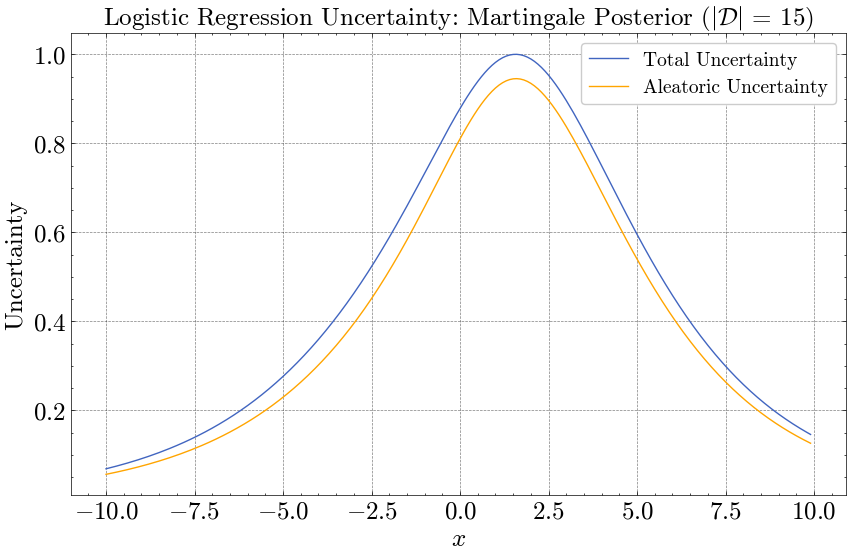

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=X_array, y=total_uncertainty, ax=ax, label='Total Uncertainty')
sns.lineplot(x=X_array, y=aleatoric_uncertainty, ax=ax, label='Aleatoric Uncertainty', color='orange')
ax.set_title(r'Logistic Regression Uncertainty: Martingale Posterior ($|\mathcal{D}|$ = 15)')
ax.set_xlabel(r'$x$')
ax.set_ylabel('Uncertainty')



plt.show()